In [1]:
# Basic setting
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# [과제] 주어진 데이터에 대해서 다항 회귀 모델 학습하기

---

## 본 과제의 목표는 다음과 같음

1. 데이터를 불러오고, 학습과 평가 데이터로 나눌 수 있음
2. `numpy`를 이용해, 간단한 다항 회귀 모델을 구현하고 경사 하강법을 통해 학습할 수 있음
3. `sklearn` 라이브러리의 클래스를 활용해 다항 회귀 모델을 정의하고 학습할 수 있음

In [2]:
# Load the dataset
with open('/content/drive/MyDrive/AI LLM/배상민 강사님_강의자료_메타코드M/regression/data/polynomial_regression.pickle', 'rb') as f:
    X, y = pickle.load(f)

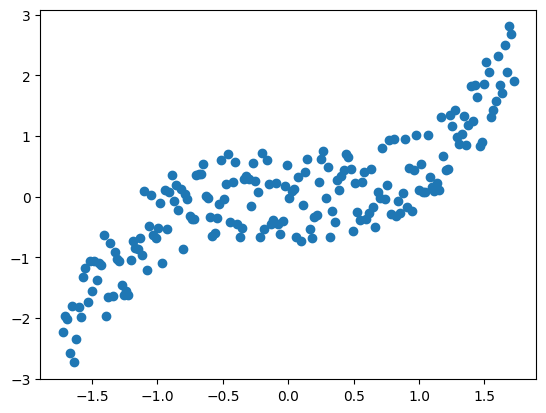

In [3]:
# Check the dataset distribution    
plt.scatter(X, y)
plt.show()

## [P.1] 학습 데이터와 평가 데이터로 나누기
---

- 이 때, 평가 데이터는 전체의 20%로 설정
- 학습과 평가 데이터셋을 각각 시각화하여 보여주기

In [4]:
# Use sklearn library
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

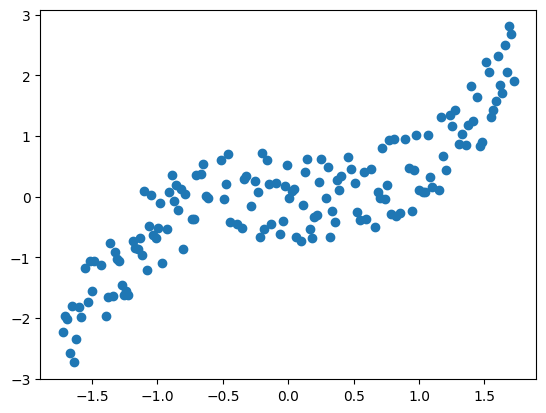

In [5]:
# Visualize train dataset  
plt.scatter(X_train, y_train)
plt.show()

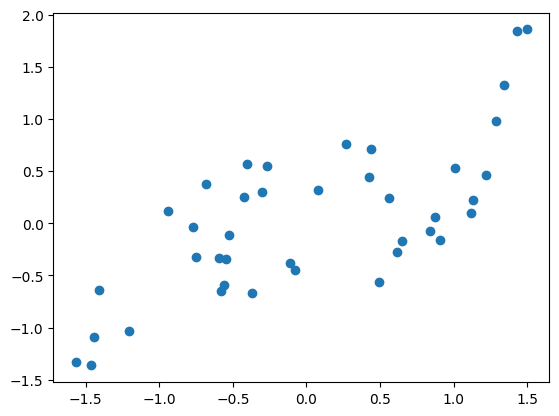

In [6]:
# Visualize train dataset  
plt.scatter(X_test, y_test)
plt.show()

## [P.2] `numpy` 라이브러리를 통해, 최적의 다항 회귀 모델 학습

---

- 데이터의 분포를 살펴보고, 가장 적합해 보이는 차수의 다항 회귀 모델을 정의
- 각 파라미터의 최적값을 경사 하강법을 통해 찾기
- 이 때의 학습 손실값과 평가 데이터에 대한 손실값을 계산

In [9]:
def gd_poly_numpy(X, y, epochs, lr):
    w1 = 0.0
    w2 = 0.0
    b = 0.0

    w1_list, w2_list, b_list, loss_list = [], [], [], []

    for i in range(epochs):
        y_pred = w1 * X + w2 * (X ** 2) + b

        loss = np.mean((y - y_pred) ** 2)

        dw1 = -2 * np.mean((y - y_pred) * X)
        dw2 = -2 * np.mean((y - y_pred) * (X ** 2))
        db = -2 * np.mean(y - y_pred)

        w1 = w1 - lr * dw1
        w2 = w2 - lr * dw2
        b = b - lr * db

        w1_list.append(w1)
        w2_list.append(w2)
        b_list.append(b)
        loss_list.append(loss)

    print('Trained model w1 : %.4f' % w1)
    print('Trained model w2 : %.4f' % w2)
    print('Trained model bias : %.4f' % b)

    return w1, w2, b, w1_list, w2_list, b_list, loss_list

In [22]:
# Training setting
epochs = 10000
learning_rate = 1e-7

w1, w2, b, w1_list, w2_list, b_list, loss_list = gd_poly_numpy(X_train, y_train, epochs, learning_rate)

Trained model w1 : 0.0018
Trained model w2 : -0.0000
Trained model bias : -0.0000


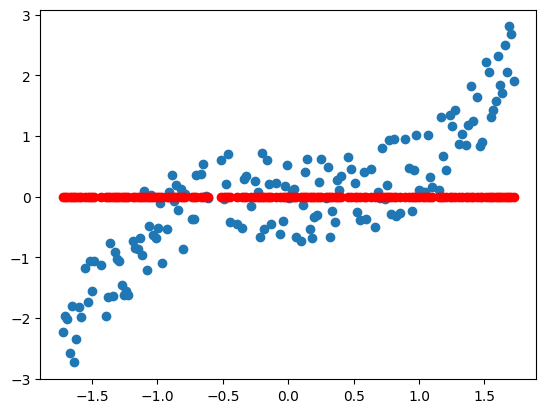

In [23]:
# Visualize the trained linear regression model
# scatter the original data
plt.scatter(X_train, y_train)   

# plot prediction results
y_pred = w1 * X_train + w2 * (X_train ** 2) + b

plt.scatter(X_train, y_pred, color='red')
plt.show()

In [24]:
# get train loss
train_loss = np.mean((y_train - y_pred)**2)
print('Train Loss for LinearRegression model : %.4f' % train_loss)

Train Loss for LinearRegression model : 1.1146


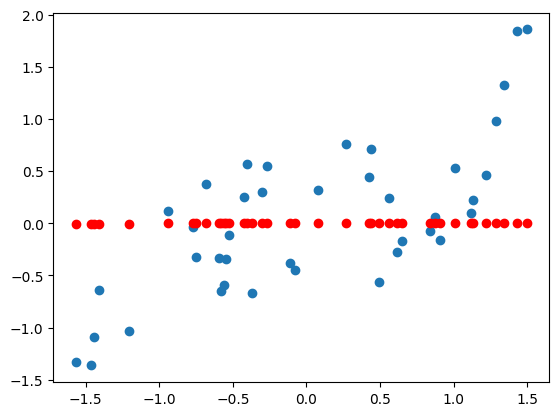

In [25]:
# Visualize the trained linear regression model
# scatter the original data
plt.scatter(X_test, y_test)   

# plot prediction results
y_pred = y_pred = w1 * X_test + w2 * (X_test ** 2) + b

plt.scatter(X_test, y_pred, color='red')
plt.show()

In [17]:
test_loss = np.mean((y_test - y_pred)**2)
print('Test Loss for LinearRegression model : %.4f' % test_loss)

Test Loss for LinearRegression model : 0.5120


## [P.3] `sklearn` 라이브러리를 통해, 최적의 다항 회귀 모델 학습

---

- 다항 회귀 모델 학습에 필요한 `sklearn`의 클래스를 사용 (Hint: [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html), [pseudo_code](https://stats.stackexchange.com/questions/58739/polynomial-regression-using-scikit-learn))
- 주어진 데이터에 대해 학습 및 평가 진행
- P.2와 마찬가지로 학습 손실값과 평가 데이터에 대한 손실값을 계산

In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [27]:
def gd_sklearn(X, y, degree):
    # preprocessing
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X.reshape(-1, 1))

    # train model
    reg = LinearRegression()
    reg.fit(X_poly, y)
    
    return poly, reg

In [28]:
degree = 2

poly, reg = gd_sklearn(X_train, y_train, degree)

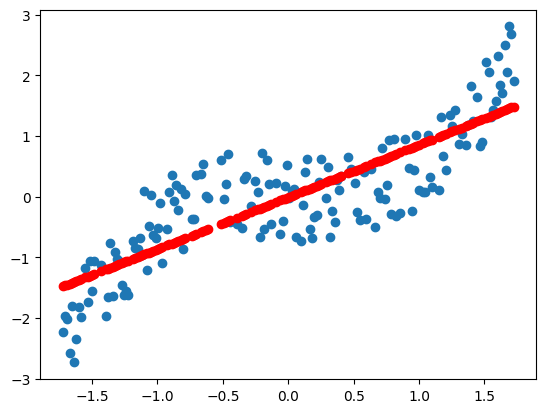

In [32]:
# Visualize the trained polynomial regression model
# scatter the original data
plt.scatter(X_train, y_train)

# plot prediction results
X_train_poly = poly.transform(X_train.reshape(-1, 1))
y_pred = reg.predict(X_train_poly)

plt.scatter(X_train, y_pred, color='red')
plt.show()

In [33]:
# get train loss
train_loss = np.mean((y_train - y_pred)**2)
print('Train Loss for LinearRegression model : %.4f' % train_loss)

Train Loss for LinearRegression model : 0.3413


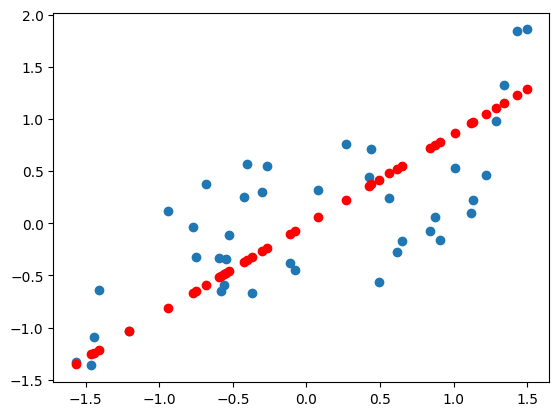

In [35]:
# Visualize the trained linear regression model
# scatter the original data
plt.scatter(X_test, y_test)   

# plot prediction results
X_test_poly = poly.transform(X_test.reshape(-1, 1))
y_pred = reg.predict(X_test_poly)

plt.scatter(X_test, y_pred, color='red')
plt.show()

In [36]:
# get test loss
test_loss = np.mean((y_test - y_pred)**2)
print('Test Loss for LinearRegression model : %.4f' % test_loss)

Test Loss for LinearRegression model : 0.3134
